# tap.garden~ — the garden, measured

The generative event loop (`taptools/garden.h`), a recreation of the *principle* behind
Eno/Chilvers' Bloom: a planted note snaps to the scale, strikes a small modal wind chime
(four mode doublets at the chosen material's ratios — free-free tube or tuned bar —
hardness-coupled, ring time scaled to pitch, each tube with its own fixed upper-mode
scatter and a fixed seat on the stereo rack),
and returns every loop pass a step quieter (`decay`) and purer (`soften`) until it retires
below the `floor`; left idle, a seeded gardener plants for you. The family's stability
inversion, one level up: **per-pass decay is the stabilizer** — the event population
converges by construction, and a fixed sixteen-bell pool hard-bounds the audio. Every trace
drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** the return staircase · **2** softening, in partials · **3** the rack:
materials, scatter, seats · **4** the scale contract, by the pitch oracle · **5** the
seeded gardener · **6** an hour of garden, in two minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def tone(x, f):
    n = np.arange(x.size)
    return 2.0 * np.abs(np.dot(x, np.exp(-2j * np.pi * f * n / sr))) / x.size

## 1 · The return staircase

One note planted at velocity 0.8 into a 0.5 s loop, `decay` 0.5, `floor` 0.05: the bloom
returns with its *fundamental* halving every pass — a measured staircase — and then
retires (the whole strike fades a shade faster still, because quieter strikes are also
duller: the hardness coupling);
`active_events` drops to zero and the garden is silent. That retirement arithmetic
(`ceil(log(floor/velocity)/log(decay))` passes, always) is the population-convergence
theorem in one plant. (Kernel scenarios: *"a planted note blooms again every loop period"*,
*"each return is quieter by the decay ratio and the bloom retires below the floor"*.)

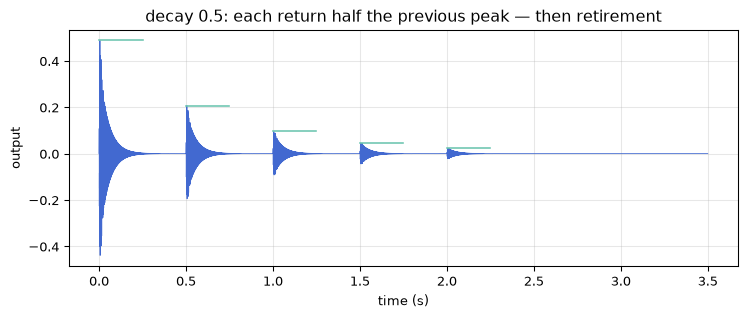

per-return peaks: [np.float64(0.488), np.float64(0.207), np.float64(0.095), np.float64(0.046), np.float64(0.022), np.float64(0.0)]
fundamental ratios: [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)]
(peaks fade a shade faster than 0.5: quieter returns are also duller — hardness)
live events after the render: 0


In [2]:
g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=0, loop_seconds=0.5,
               decay=0.5, floor=0.05, bell=(0.002, 0.05, 1.0), scale=0)
g.note(69, 0.8)
y, _ = g.process(int(3.5 * sr))  # spread 0: both busses identical, read the left

t = np.arange(y.size) / sr
fig, ax = plt.subplots()
ax.plot(t, y, color=C[0], lw=0.6)
marks = [np.abs(y[int(k * 0.5 * sr) : int((k + 1) * 0.5 * sr)]).max() for k in range(5)]
for k, v in enumerate(marks):
    ax.plot([k * 0.5, k * 0.5 + 0.25], [v, v], color=C[3], lw=1.2)
ax.set_xlabel("time (s)"); ax.set_ylabel("output")
ax.set_title("decay 0.5: each return half the previous peak — then retirement")
plt.show()

peaks = [np.abs(y[int(k * 0.5 * sr) : int((k + 1) * 0.5 * sr)]).max() for k in range(6)]
fund = [tone(y[int(k * 0.5 * sr) : int((k + 1) * 0.5 * sr)], 440.0) for k in range(5)]
print("per-return peaks:", [round(p, 3) for p in peaks])
print("fundamental ratios:", [round(fund[k + 1] / fund[k], 3) for k in range(4)])
print("(peaks fade a shade faster than 0.5: quieter returns are also duller — hardness)")
print("live events after the render:", g.active_events)

## 2 · Softening, in modes

With `decay` held at 1.0 (velocity still) and `soften` 0.6, only the timbre moves: the
chime's second mode (2.756× the fundamental — the free-free bar ratio) fades pass by pass
while the fundamental holds — each return is *purer*, the strike ringing further down
toward its fundamental. The tape family's generation loss, restated in modes instead of
passbands.

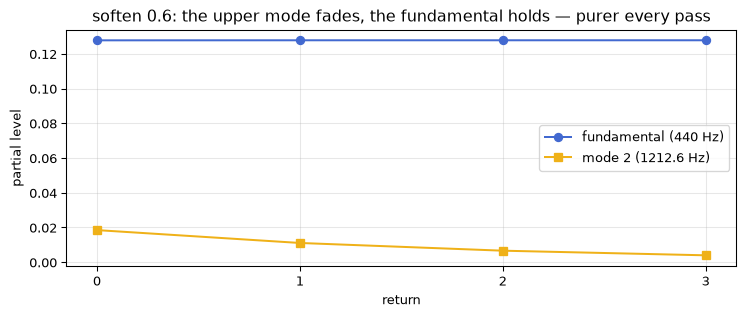

mode2/fundamental per return: [np.float64(0.145), np.float64(0.087), np.float64(0.052), np.float64(0.031)]


In [3]:
g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=0, loop_seconds=0.5,
               decay=1.0, floor=0.001, soften=0.6, bell=(0.005, 0.06, 1.0), scale=0)
g.note(69, 0.8)  # 440 Hz fundamental -> second chime mode at 2.756x = 1212.6 Hz
y, _ = g.process(int(2.5 * sr))

loop = int(0.5 * sr)
passes = np.arange(4)
fund = [tone(y[k * loop : k * loop + int(0.2 * sr)], 440.0) for k in passes]
side = [tone(y[k * loop : k * loop + int(0.2 * sr)], 440.0 * 2.756) for k in passes]

fig, ax = plt.subplots()
ax.plot(passes, fund, "o-", color=C[0], label="fundamental (440 Hz)")
ax.plot(passes, side, "s-", color=C[1], label="mode 2 (1212.6 Hz)")
ax.set_xticks(passes)
ax.set_xlabel("return"); ax.set_ylabel("partial level")
ax.set_title("soften 0.6: the upper mode fades, the fundamental holds — purer every pass")
ax.legend()
plt.show()

print("mode2/fundamental per return:",
      [round(s / f, 3) for s, f in zip(side, fund)])

## 3 · The rack: two materials, fixed flaws, fixed seats

`material` swaps the mode-ratio table under every tube — 0 is the wind-chime rack (the
free-free tube's 1 : 2.756 : 5.404 : 8.933), 1 the tuned bar (the mallet instrument's
double-octave 1 : 4 : 10 : 20) — instant, and read at strike time, so live blooms re-voice
at their next return. And the tube is the identity: each pitch's upper modes sit a fixed
few cents off the ideal ratios (bounded by ±3 cents; the fundamental stays true), and each
tube hangs at a fixed seat on the stereo rack, both drawn from a stateless hash of the
pitch — no RNG consumed, so the seed triad below is untouched. Same tube: same flaws, same
seat, every strike, every instance. (Kernel scenarios: *"material re-voices the rack…"*,
*"each tube's upper modes sit a fixed few cents off…"*, *"the rack is stereo…"*.)

chime material: level at 2.756f 0.0426   at 4f 0.0001
bar material: level at 2.756f 0.0002   at 4f 0.0236
tube 60: mode-2 scatter +1.25 cents — the tube's own, every strike
tube 69: mode-2 scatter +2.75 cents — the tube's own, every strike


tube 76: mode-2 scatter -0.75 cents — the tube's own, every strike


tube 84: mode-2 scatter -2.25 cents — the tube's own, every strike


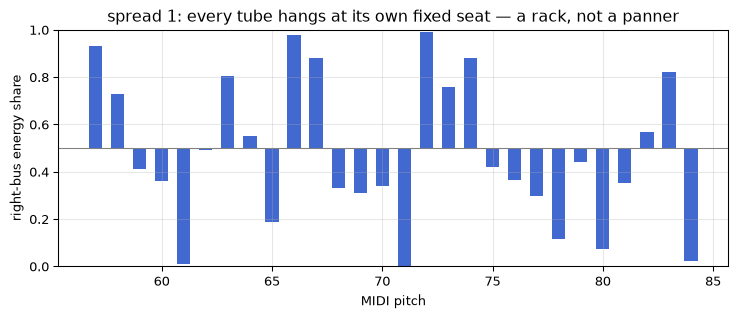

In [4]:
# (a) material: the second partial moves from 2.756x (chime) to 4x (bar)
def partials(material):
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=0, loop_seconds=2.0,
                   material=material, bell=(0.001, 0.5, 1.0), scale=0)
    g.note(69, 0.9)
    y, _ = g.process(int(0.2 * sr))
    return tone(y, 440.0 * 2.756), tone(y, 440.0 * 4.0)

for name, m in (("chime", 0), ("bar", 1)):
    a, b = partials(m)
    print(f"{name} material: level at 2.756f {a:.4f}   at 4f {b:.4f}")

# (b) scatter: each tube's mode 2 sits its own fixed cents off — scan a probe across it
def detune(pitch):
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=0, loop_seconds=2.0,
                   bell=(0.001, 0.5, 1.0), scale=0)
    g.note(float(pitch), 0.9)
    y, _ = g.process(int(0.25 * sr))
    f2 = 440.0 * 2 ** ((pitch - 69) / 12) * 2.756
    cs = np.arange(-6.0, 6.01, 0.25)
    mags = [tone(y[int(0.01 * sr) : int(0.2 * sr)], f2 * 2 ** (c / 1200)) for c in cs]
    return cs[int(np.argmax(mags))]

for p in (60, 69, 76, 84):
    print(f"tube {p}: mode-2 scatter {detune(p):+.2f} cents — the tube's own, every strike")

# (c) seats: at spread 1, each tube's left/right balance is keyed by its pitch
pitches = np.arange(57, 85)
shares = []
for p in pitches:
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=1.0, loop_seconds=2.0,
                   bell=(0.001, 0.1, 0.5), scale=0)
    g.note(float(p), 0.8)
    l, r = g.process(int(0.3 * sr))
    shares.append(np.sum(r * r) / (np.sum(l * l) + np.sum(r * r)))

fig, ax = plt.subplots()
ax.bar(pitches, np.asarray(shares) - 0.5, bottom=0.5, color=C[0], width=0.6)
ax.axhline(0.5, color="gray", lw=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel("MIDI pitch"); ax.set_ylabel("right-bus energy share")
ax.set_title("spread 1: every tube hangs at its own fixed seat — a rack, not a panner")
plt.show()

## 4 · The scale contract, by the pitch oracle

Plant every chromatic pitch from 60 to 72 into a C major-pentatonic garden and measure what
actually sounds with the DspTap YIN detector: every bloom lands on {C, D, E, G, A}, whatever
you planted. The chime's upper modes are inharmonic, so the pitch oracle reads each strike in
its ring-down, where the fundamental is all that remains. Quantization happens at entry —
the instrument makes wrong notes impossible,
which is most of why Bloom-style instruments feel effortless. (Kernel scenario: *"every
bloom lands on the scale"*.)

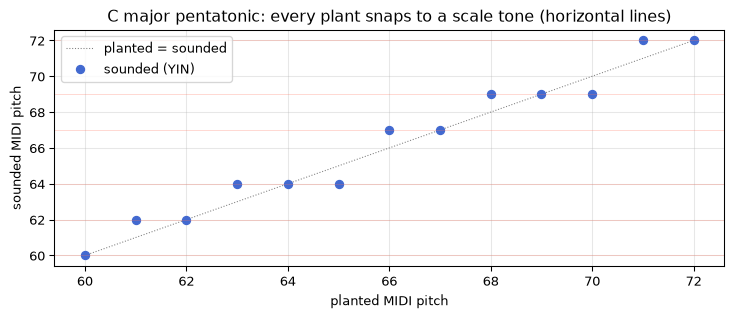

all sounded pitches on the scale: True


In [5]:
pent = {0, 2, 4, 7, 9}
planted = np.arange(60, 73)
sounded = []
for p in planted:
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, spread=0, loop_seconds=2.0,
                   scale=3, root=0, bell=(0.01, 0.5, 0.4))
    g.note(float(p), 0.8)
    y, _ = g.process(int(0.6 * sr))
    periods = tap.Yin().track(y[int(0.25 * sr):], hop=512)
    hz = sr / np.median(periods[periods > 0])
    sounded.append(69 + 12 * np.log2(hz / 440.0))

fig, ax = plt.subplots()
ax.plot(planted, planted, ":", color="gray", lw=0.8, label="planted = sounded")
ax.plot(planted, sounded, "o", color=C[0], label="sounded (YIN)")
for m in range(60, 73):
    if m % 12 in pent:
        ax.axhline(m, color=C[2], lw=0.5, alpha=0.4)
ax.set_xlabel("planted MIDI pitch"); ax.set_ylabel("sounded MIDI pitch")
ax.set_title("C major pentatonic: every plant snaps to a scale tone (horizontal lines)")
ax.legend()
plt.show()

ok = all(round(s) % 12 in pent for s in sounded)
print("all sounded pitches on the scale:", ok)

## 5 · The seeded gardener is wind

Idle for half a second, then the garden plays itself — and the gardener is wind: strikes
arrive on a calm/gust cycle, each gust catching up to five neighboring tubes within a
fraction of a second (`gust` sizes the clusters; calms stretch so the average stays near
one strike per pass). The randomness rides the family's seeded xorshift64* — same seed,
bit-identical garden; different seed, different garden; gardener disabled, the seed cannot
matter at all (the rng is never consumed). The library's first randomized event source,
with the tr808 seed triad as its contract.

same seed bit-exact: True   different seed differs: True


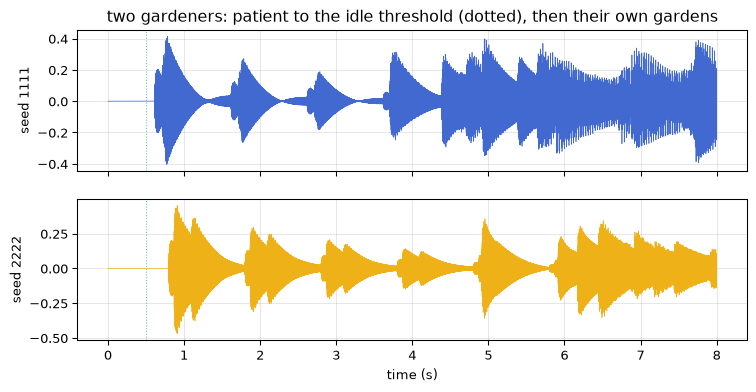

In [6]:
def render_idle(seed, seconds=8.0):
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0.5, spread=0, loop_seconds=1.0,
                   seed=seed, bell=(0.01, 0.6, 0.8), decay=0.7)
    return g.process(int(seconds * sr))[0]  # spread 0: left is the render

a = render_idle(1111)
b = render_idle(1111)
c = render_idle(2222)
print("same seed bit-exact:", bool(np.all(a == b)),
      "  different seed differs:", bool(np.any(a != c)))

t = np.arange(a.size) / sr
fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
for ax, y, seed, color in [(axes[0], a, 1111, C[0]), (axes[1], c, 2222, C[1])]:
    ax.plot(t, y, color=color, lw=0.5)
    ax.axvline(0.5, color=C[3], ls=":", lw=0.8)
    ax.set_ylabel(f"seed {seed}")
axes[1].set_xlabel("time (s)")
axes[0].set_title("two gardeners: patient to the idle threshold (dotted), then their own gardens")
plt.show()

## 6 · An hour of garden, in two minutes

A handful of hand-planted notes to start, then the gardener takes over — wind striking
chimes, literally now, across the stereo rack at `spread` 0.7: `decay` 0.85 and
`soften` 0.9 keep each bloom returning for a dozen passes, softening as it goes; the
population breathes around its converged size instead of piling up. This render would go on
— unrepeating, bounded, self-tending — for exactly as long as you let it.

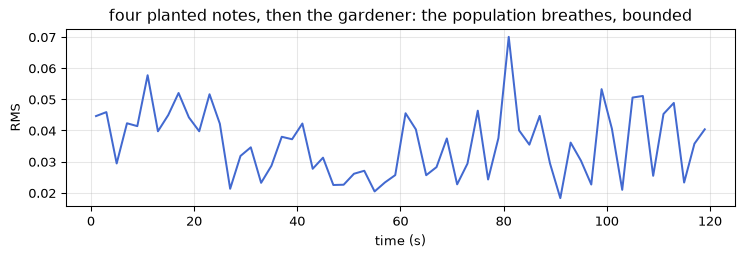

live events at the end: 23  ringing bells: 16


In [7]:
from IPython.display import Audio

g = tap.Garden(sr, smooth_ms=0, loop_seconds=6.0, decay=0.85, soften=0.9, floor=0.02,
               bell=(0.006, 3.0, 0.9), scale=3, root=9, idle_seconds=4.0, gust=0.6, seed=2008,
               spread=0.7, level=0.35)

left, right = [], []
plants = [(0.0, 69, 0.7), (1.2, 76, 0.55), (2.6, 64, 0.6), (4.0, 81, 0.4)]
cursor = 0.0
for when, pitch, vel in plants:
    n = int((when - cursor) * sr)
    if n > 0:
        l, r = g.process(n)
        left.append(l); right.append(r)
    g.note(pitch, vel)
    cursor = when
l, r = g.process(int((120.0 - cursor) * sr))
left.append(l); right.append(r)
y_l, y_r = np.concatenate(left), np.concatenate(right)
y = 0.5 * (y_l + y_r)  # the mono sum, for the RMS trace

win = int(2.0 * sr)
frames = y[: y.size // win * win].reshape(-1, win)
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot((np.arange(frames.shape[0]) + 0.5) * 2.0, np.sqrt((frames ** 2).mean(axis=1)),
        color=C[0])
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS")
ax.set_title("four planted notes, then the gardener: the population breathes, bounded")
plt.show()
print("live events at the end:", g.active_events, " ringing bells:", g.active_voices)

# Preview: first 30 s in stereo — the plants and the first gusts, the rack at spread 0.7 —
# embedded at 16 kHz to keep the executed notebook at the house size (the bells live below
# 4 kHz); tools/render writes the full-rate, full-length WAVs.
Audio(np.clip(np.stack([y_l, y_r])[:, : int(30 * sr) : 3], -1, 1), rate=int(sr / 3))